# Telecom Customer Churn Prediction

## Objective

The main goal of this project is to predict whether a customer is likely to leave the telecom company.

This model can help the company identify customers who may churn and take action early by providing suitable retention offers.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

## Load the Dataset

First, we load the customer dataset and inspect the available information.

In [35]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [36]:
print("Rows and Columns:", df.shape)

Rows and Columns: (7043, 21)


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [38]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [39]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Customer Churn Distribution

The target variable is `Churn`.

- Yes means the customer left the company.
- No means the customer stayed with the company.

In [40]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

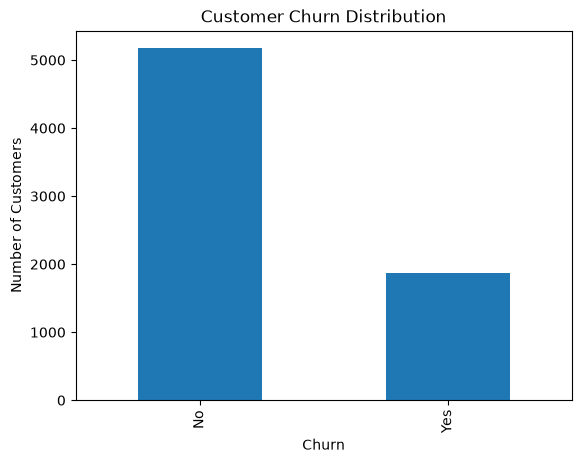

In [41]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

## Relevant Customer Features

The dataset contains customer information such as:

- Gender
- Senior citizen status
- Partner and dependents
- Tenure
- Phone and internet services
- Online security and support services
- Contract type
- Payment method
- Monthly charges
- Total charges

These features may influence whether a customer stays or leaves.

The customer ID is not useful for predicting churn, so it will be removed.

In [42]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [43]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## Separate Features and Target

The input features are the customer attributes.

The target variable is `Churn`.

We also remove `customerID` because it is only an identifier and does not provide useful information for predicting customer behavior.

In [44]:
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"].map({"No": 0, "Yes": 1})
print("Input features:", X.shape)
print("Target:", y.shape)

Input features: (7043, 19)
Target: (7043,)


## Train-Test Split

We divide the data into two parts:

- 80% for training the model
- 20% for testing the model

The test data represents unseen customer records.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 5634
Testing records: 1409


In [46]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:", list(numeric_features))
print("Categorical features:", list(categorical_features))

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/var/folders/_y/fkwwp_7j66x94hxsdjcq13_r0000gn/T/ipykernel_5885/2138717209.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


## Build the Churn Prediction Model

Logistic Regression is used to predict the probability of customer churn.

Categorical features are converted into numerical form using One-Hot Encoding.

Numerical features are scaled so that they can work properly with the model.

In [47]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [48]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

In [49]:
y_pred = model.predict(X_test)
churn_probability = model.predict_proba(X_test)[:, 1]
pd.DataFrame({
    "Actual Churn": y_test.values,
    "Predicted Churn": y_pred,
    "Churn Probability": churn_probability
}).head(10)

,Actual Churn,Predicted Churn,Churn Probability
0,0,0,0.045294
1,0,1,0.684411
2,0,0,0.058721
3,0,0,0.401704
4,0,0,0.021548
5,0,1,0.603935
6,0,0,0.449225
7,0,0,0.130055
8,0,0,0.002881
9,1,0,0.395179


## Customer Classification

The model classifies customers into two groups:

- Likely to churn
- Likely to stay

In [50]:
result = pd.DataFrame({
    "Actual": y_test.map({0: "Stay", 1: "Churn"}).values,
    "Predicted": pd.Series(y_pred).map({0: "Likely to Stay", 1: "Likely to Churn"}).values,
    "Churn Probability": churn_probability
})

result.head(10)

,Actual,Predicted,Churn Probability
0,Stay,Likely to Stay,0.045294
1,Stay,Likely to Churn,0.684411
2,Stay,Likely to Stay,0.058721
3,Stay,Likely to Stay,0.401704
4,Stay,Likely to Stay,0.021548
5,Stay,Likely to Churn,0.603935
6,Stay,Likely to Stay,0.449225
7,Stay,Likely to Stay,0.130055
8,Stay,Likely to Stay,0.002881
9,Churn,Likely to Stay,0.395179


## Model Evaluation

We evaluate the model using accuracy, precision, recall, F1-score and ROC-AUC.

These metrics help us understand how well the model identifies customers who may churn.

In [51]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, churn_probability)

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))
print("ROC-AUC:", round(auc, 3))

Accuracy: 0.806
Precision: 0.657
Recall: 0.559
F1 Score: 0.604
ROC-AUC: 0.842


In [52]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[926 109]
 [165 209]]


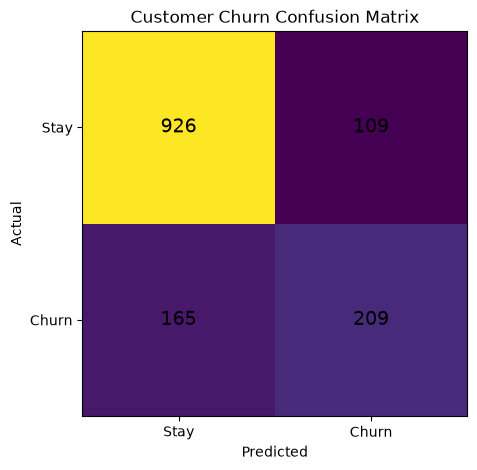

In [53]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Customer Churn Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Stay", "Churn"])
plt.yticks([0, 1], ["Stay", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

plt.show()

## Confusion Matrix Analysis

The model correctly identified 209 customers who actually churned.

The model incorrectly classified 109 customers who actually stayed as customers likely to churn.

The model missed 165 customers who actually churned.

In [54]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("Correctly identified churn customers:", tp)
print("Non-churn customers incorrectly flagged as churn:", fp)
print("Churn customers missed by the model:", fn)
print("Correctly identified non-churn customers:", tn)

Correctly identified churn customers: 209
Non-churn customers incorrectly flagged as churn: 109
Churn customers missed by the model: 165
Correctly identified non-churn customers: 926


In [55]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Stay", "Churn"]
))

              precision    recall  f1-score   support

        Stay       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## Prediction for an Unseen Customer

The following customer record was not used during model training.

The model will predict whether this customer is likely to churn and calculate the probability of churn.

In [56]:
customer = X_test.iloc[[0]]

prediction = model.predict(customer)[0]
probability = model.predict_proba(customer)[0][1]

print("Prediction:", "Likely to Churn" if prediction == 1 else "Likely to Stay")
print("Churn Probability:", round(probability, 2))

Prediction: Likely to Stay
Churn Probability: 0.05


In [57]:
unseen_customers = X_test.iloc[:10].copy()

unseen_customers["Churn Probability"] = model.predict_proba(X_test.iloc[:10])[:, 1]

unseen_customers["Prediction"] = np.where(
    model.predict(X_test.iloc[:10]) == 1,
    "Likely to Churn",
    "Likely to Stay"
)

unseen_customers[["Churn Probability", "Prediction"]]

,Churn Probability,Prediction
437,0.045294,Likely to Stay
2280,0.684411,Likely to Churn
2235,0.058721,Likely to Stay
4460,0.401704,Likely to Stay
3761,0.021548,Likely to Stay
5748,0.603935,Likely to Churn
3568,0.449225,Likely to Stay
2976,0.130055,Likely to Stay
5928,0.002881,Likely to Stay
1639,0.395179,Likely to Stay


## Business Interpretation

The model can help the telecom company identify customers who are at risk of leaving.

The model correctly identified 209 customers who actually churned. This means the company can potentially target these customers with retention offers.

The model also incorrectly flagged 109 customers who actually stayed. This may result in some unnecessary retention offers, but it is generally less harmful than completely missing a customer who is about to leave.

The model missed 165 customers who actually churned. These customers are important because the company may lose their revenue without having the opportunity to take preventive action.

From a business perspective, missing a customer who is going to leave can be more costly than incorrectly flagging a loyal customer. Therefore, improving recall for the churn class can be important.

## Business Decision

It is generally more costly to miss a customer who is actually going to leave.

If a loyal customer is wrongly identified as a churn customer, the company may offer them an unnecessary discount or retention offer.

However, if a customer who is actually going to leave is missed, the company may lose that customer and future revenue.

Therefore, the company should focus on reducing false negatives while keeping false positives at a reasonable level.

## Suggested Improvement

One improvement is to lower the churn probability threshold.

Instead of classifying a customer as likely to churn only when the probability is 50% or higher, the company could use a lower threshold such as 40%.

This can help identify more customers who are at risk of leaving and improve churn recall.

The company should choose the threshold based on the cost of retention offers and the financial loss caused by customer churn.

In [58]:
new_threshold = 0.40

y_pred_new = (churn_probability >= new_threshold).astype(int)

print("Accuracy:", round(accuracy_score(y_test, y_pred_new), 3))
print("Precision:", round(precision_score(y_test, y_pred_new), 3))
print("Recall:", round(recall_score(y_test, y_pred_new), 3))
print("F1 Score:", round(f1_score(y_test, y_pred_new), 3))

Accuracy: 0.778
Precision: 0.569
Recall: 0.668
F1 Score: 0.615


# Conclusion

In this project, a Logistic Regression model was developed to predict telecom customer churn.

The dataset contained 7,043 customer records with information about customer demographics, services, contracts, payments and charges.

The customer ID was removed because it does not provide useful information for predicting churn. The `TotalCharges` column was converted into numeric format and missing values were handled during preprocessing.

The model achieved an accuracy of approximately 81% and a ROC-AUC score of approximately 0.84.

The model correctly identified 209 customers who actually churned and incorrectly classified 109 customers who actually stayed as churn customers.

However, the model missed 165 customers who actually churned. Since losing a customer can result in future revenue loss, reducing these missed churn cases is important.

One possible improvement is to lower the probability threshold so that more high-risk customers can be identified early.

Overall, this model can help the telecom company identify customers who are more likely to leave and take proactive retention actions.